In [1]:
import numpy as np
import matplotlib.pyplot as plt
from visualization import draw_field_with_robot
from particle_filter import *
from Localization_metrics import *

## Настройка параметров модели фильтра частиц

In [2]:
particles_count = 5000  # hyperparam: particles count 

# landmark coords
left_coord = Coord(-1, 5)
right_coord = Coord(1, 5)
lm = LandMark(left_coord, right_coord)

# standard deviation of noise for each dimension (x, y, theta)
system_noise = State(0.4, 0.4, 0.2)
sens_noise = np.array([0.08, 0.08, 0.04])

# initial state
state0 = State(0, 0, np.pi/2)

pf = ParticleFilter(particles_count, state0, lm, system_noise, sens_noise)
local_metrics = LocalizationMetrics()

## Хождение робота на поле

In [3]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt

# steps_cnt = int(input())
# trajectory = [(pf.state.x, pf.state.y)]

# fig, ax = plt.subplots(figsize=(8, 10))
# draw_field_with_robot(pf.state, pf.particles, ax=ax)
# display(fig)

# for i in range(steps_cnt):
#     step = State(*map(float, input().split()))
#     est_state = pf.simulate(step)
    
#     local_metrics.update(pf.ideal_state, est_state)
#     trajectory.append((est_state.x, est_state.y))

#     draw_field_with_robot(est_state, pf.particles, ax=ax)

#     traj = np.array(trajectory)
#     ax.plot(traj[:, 0], traj[:, 1], color='red', linewidth=2)   # от стартовой точки
#     ax.plot(traj[:, 0], traj[:, 1], 'ko', markersize=3)          # узловые точки пути

#     clear_output(wait=True)
#     display(fig)

#     # print("estimated state: ", est_state)
#     # print("true state: ", pf.state)

# plt.close(fig)

# res = local_metrics.summary()

In [4]:
# # метрики оценки качества локализации
# res

## Эксперменты

#### Насколько сильно шум движения ухудшает локализацию без PF?
#### Насколько PF компенсирует эту ошибку?
#### Как качество PF зависит от шума сенсора и количества частиц?

In [5]:
# заданный маршрут робота
steps = [
    # ↑ к воротам
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),

    # → вправо
    State(0, 0, -np.pi / 2),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),

    # ↑
    State(0, 0, np.pi / 2),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),

    # ←
    State(0, 0, np.pi / 2),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),

    # ↑ к воротам
    State(0, 0, -np.pi / 2),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),
]

# начальное положение робота
state0 = State(0, -4, np.pi / 2)

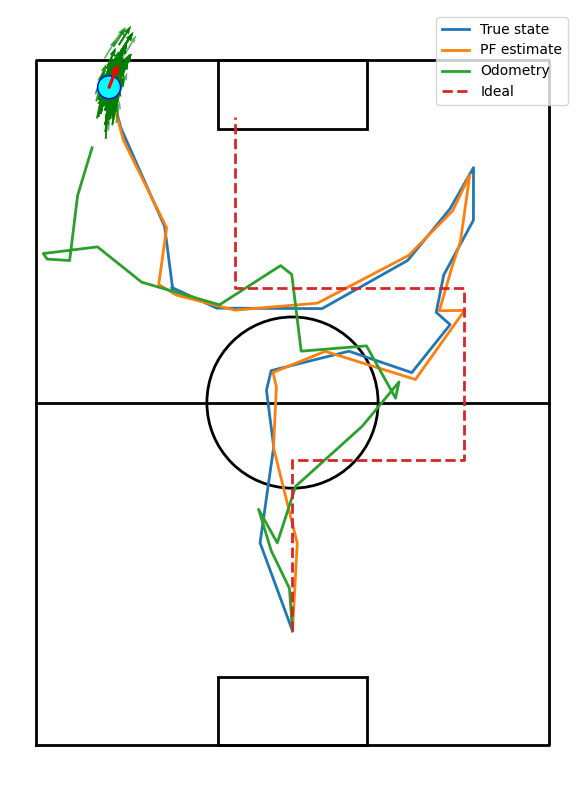

In [6]:
# насколько PF определяет фактическое положение робота
pf = ParticleFilter(particles_count, state0, lm, system_noise, sens_noise)

pf_metrics_state = LocalizationMetrics()
no_pf_metrics_state = LocalizationMetrics()
pf_metrics_ideal_state = LocalizationMetrics()
no_pf_metrics_ideal_state = LocalizationMetrics()

fig, ax = plt.subplots(figsize=(8, 10))
draw_field_with_robot(pf.state, pf.particles, ax=ax)
display(fig)

true_trajectory = [(pf.state.x, pf.state.y)]
pf_trajectory = [(pf.state.x, pf.state.y)]
no_pf_trajectory = [(pf.no_pf_state.x, pf.no_pf_state.y)]
ideal_trajectory = [(pf.ideal_state.x, pf.ideal_state.y)]

for step_i in steps:

    est_state = pf.simulate(step_i)

    pf_metrics_state.update(pf.state, est_state)
    no_pf_metrics_state.update(pf.state, pf.no_pf_state)

    pf_metrics_ideal_state.update(pf.ideal_state, est_state)
    no_pf_metrics_ideal_state.update(pf.ideal_state, pf.no_pf_state)

    true_trajectory.append((pf.state.x, pf.state.y))
    pf_trajectory.append((est_state.x, est_state.y))
    no_pf_trajectory.append((pf.no_pf_state.x, pf.no_pf_state.y))
    ideal_trajectory.append((pf.ideal_state.x, pf.ideal_state.y))

    draw_field_with_robot(est_state, pf.particles, ax=ax)

    true_traj = np.array(true_trajectory)
    pf_traj = np.array(pf_trajectory)
    no_pf_traj = np.array(no_pf_trajectory)
    id_traj = np.array(ideal_trajectory)

    ax.plot(true_traj[:, 0], true_traj[:, 1],
            linewidth=2, label='True state')

    ax.plot(pf_traj[:, 0], pf_traj[:, 1],
            linewidth=2, label='PF estimate')

    ax.plot(no_pf_traj[:, 0], no_pf_traj[:, 1],
            linewidth=2, label='Odometry')
    
    ax.plot(id_traj[:, 0], id_traj[:, 1],
            linewidth=2, linestyle='--', label='Ideal')

    ax.legend()

    clear_output(wait=True)
    display(fig)

plt.close(fig)

res_pf_state = pf_metrics_state.summary()
res_no_pf_state = no_pf_metrics_state.summary()
res_pf_ideal_state = pf_metrics_ideal_state.summary()
res_no_pf_ideal_state = no_pf_metrics_ideal_state.summary()

Качество локализации

In [7]:
res_pf_state

{'position_rmse': np.float64(0.25744459987443796),
 'position_mae': np.float64(0.20051748993753898),
 'position_max': np.float64(0.6516225141611661),
 'position_final': np.float64(0.06882020376221228),
 'angle_rmse': np.float64(0.058775333282980256)}

In [8]:
res_no_pf_state

{'position_rmse': np.float64(2.407619136963746),
 'position_mae': np.float64(2.253008745806606),
 'position_max': np.float64(3.7914139415546995),
 'position_final': np.float64(1.1686697543495403),
 'angle_rmse': np.float64(0.49775171189148015)}

res_pf_state всегда лучше res_no_pf_state

Отклонение от заданного маршрута

In [9]:
res_pf_ideal_state

{'position_rmse': np.float64(1.674399987118122),
 'position_mae': np.float64(1.5525021022362246),
 'position_max': np.float64(2.6436140094293084),
 'position_final': np.float64(2.275406343267919),
 'angle_rmse': np.float64(0.30300340434804246)}

In [10]:
res_no_pf_ideal_state

{'position_rmse': np.float64(2.5051651652456006),
 'position_mae': np.float64(2.2741499004131054),
 'position_max': np.float64(3.643315893296845),
 'position_final': np.float64(2.5682249521633906),
 'angle_rmse': np.float64(0.5213384093938299)}

### Усредняем по n seedам

In [11]:
pf_ideal_rmses = []
no_pf_ideal_rmses = []
particles_count = 5000

n = 30
for seed_i in range(n):
    np.random.seed(seed_i)
    random.seed(seed_i)
    pf = ParticleFilter(particles_count, state0, lm, system_noise, sens_noise)

    pf_metrics_ideal_state = LocalizationMetrics()
    no_pf_metrics_ideal_state = LocalizationMetrics()
    
    for step_i in steps:
        est_state = pf.simulate(step_i)

        # Близость к идеальной траектории

        # ideal и оценка PF
        pf_metrics_ideal_state.update(
            pf.ideal_state,
            est_state
        )

        # ideal и оценка одометрии
        no_pf_metrics_ideal_state.update(
            pf.ideal_state,
            pf.no_pf_state
        )

    pf_result = pf_metrics_ideal_state.summary()
    no_pf_result = no_pf_metrics_ideal_state.summary()

    pf_pos_rmse = pf_result["position_rmse"]
    odom_pos_rmse = no_pf_result["position_rmse"]

    pf_ideal_rmses.append(pf_pos_rmse)
    no_pf_ideal_rmses.append(odom_pos_rmse)

    print(f"Iter num:{seed_i}: pf_pos_rmse: {pf_pos_rmse}, odom_pos_rmse: {odom_pos_rmse}")
    

Iter num:0: pf_pos_rmse: 2.9264593732433073, odom_pos_rmse: 3.2329992850882254
Iter num:1: pf_pos_rmse: 3.6384073815359543, odom_pos_rmse: 1.3431601561569808
Iter num:2: pf_pos_rmse: 4.076598141960681, odom_pos_rmse: 2.707988196231928
Iter num:3: pf_pos_rmse: 1.3476907116848464, odom_pos_rmse: 2.4950443953025414
Iter num:4: pf_pos_rmse: 4.055110888933598, odom_pos_rmse: 0.9767158356175787
Iter num:5: pf_pos_rmse: 3.0409300940401054, odom_pos_rmse: 2.624804839433103
Iter num:6: pf_pos_rmse: 2.927851658387064, odom_pos_rmse: 3.3576239584537144
Iter num:7: pf_pos_rmse: 1.9344295817139898, odom_pos_rmse: 1.6528421912927413
Iter num:8: pf_pos_rmse: 1.6114879971366498, odom_pos_rmse: 2.1211194008894703
Iter num:9: pf_pos_rmse: 1.8630994661644078, odom_pos_rmse: 1.2563020317724307
Iter num:10: pf_pos_rmse: 2.36851717350448, odom_pos_rmse: 2.5638560890150583
Iter num:11: pf_pos_rmse: 2.786169806451865, odom_pos_rmse: 1.3391868240207843
Iter num:12: pf_pos_rmse: 1.9162354884326418, odom_pos_rms

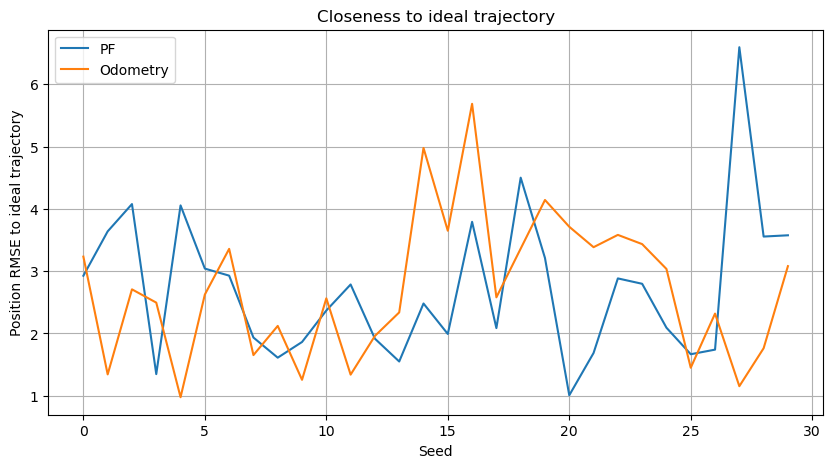

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    range(n),
    pf_ideal_rmses,
    label="PF"
)

ax.plot(
    range(n),
    no_pf_ideal_rmses,
    label="Odometry"
)

ax.set_xlabel("Seed")
ax.set_ylabel("Position RMSE to ideal trajectory")
ax.set_title("Closeness to ideal trajectory")
ax.legend()
ax.grid()

plt.show()

In [13]:
print(np.mean(pf_ideal_rmses))
print(np.mean(no_pf_ideal_rmses))

2.7234582051201843
2.7093085202927996
